In [ ]:
# v1 - Overfitting one image, Autoencoder ViT encoder + CNN decoder - 02/02/26

# --- 1. CONFIGURACIÓ ---
!pip install medmnist

import torch
from torch import nn, optim
from medmnist import PneumoniaMNIST
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
from tqdm.notebook import tqdm
import numpy as np
import matplotlib.pyplot as plt
import gc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 9.5 MB/s eta 0:00:00


In [ ]:
# Neteja
torch.cuda.empty_cache()
gc.collect()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f" Usant dispositiu: {DEVICE}")

# --- 2. ENCODER (ViT)  ---

class PatchEmbedding(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_channels=1, embed_dim=64):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
            x = self.proj(x)  # (Batch, embed_dim, H//patch_size, W//patch_size)
            x = x.flatten(2).transpose(1, 2)  # (Batch, num_patches, embed_dim)

            return x

class MHSelfAttentionBlock(nn.Module):
    def __init__(self, channels, embed_dim, num_heads=4, mlp_hidden=48, embed_hidden=48):
        super().__init__()
        self.channels = channels
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.embed_hidden = embed_hidden
        self.head_dim = self.embed_hidden // num_heads
        self.scale = self.head_dim ** -0.5

        self.norm1 = nn.LayerNorm((channels, self.embed_dim))

        self.preadapt = nn.Linear(self.embed_dim, self.embed_hidden)

        self.qW = nn.Linear(self.embed_hidden, self.embed_hidden)
        self.kW = nn.Linear(self.embed_hidden, self.embed_hidden)
        self.vW = nn.Linear(self.embed_hidden, self.embed_hidden)
        self.oW = nn.Linear(self.embed_hidden, self.embed_hidden)

        self.postadapt = nn.Linear(self.embed_hidden, self.embed_dim)

        self.norm2 = nn.LayerNorm((channels, self.embed_dim))

        self.mlp = nn.Sequential(
            nn.Linear(self.embed_dim, mlp_hidden),
            nn.SiLU(),
            nn.Linear(mlp_hidden, mlp_hidden),
            nn.SiLU(),
            nn.Linear(mlp_hidden, mlp_hidden),
            nn.SiLU(),
            nn.Linear(mlp_hidden, self.embed_dim),
            nn.SiLU()
        )

    def forward(self, latent):
        latent = self.norm1(latent)
        latent = self.preadapt(latent)

        batch_size, _, _ = latent.shape

        q = self.qW(latent).reshape(batch_size, self.channels, self.num_heads, self.head_dim)
        k = self.kW(latent).reshape(batch_size, self.channels, self.num_heads, self.head_dim)
        v = self.vW(latent).reshape(batch_size, self.channels, self.num_heads, self.head_dim)

        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        latent = (attn @ v).transpose(0, 1).reshape(batch_size, self.channels, self.embed_hidden)

        latent = self.postadapt(latent)
        latent = self.norm2(latent)

        x = latent + self.mlp(latent)
        return x

class ViTEncoder(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_channels=1, embed_dim=64, num_heads=4, depth=6, mask_ratio=0.5, device = DEVICE):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.in_channels = in_channels
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.depth = depth
        self.mask_ratio = mask_ratio
        self.device = device

        #patchify
        self.patch_embed = PatchEmbedding(self.img_size,
                                          self.patch_size,
                                          self.in_channels,
                                          self.embed_dim)
        self.num_patches = self.patch_embed.num_patches

        #positional embedding
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_patches, self.embed_dim))

        #self-attention blocks
        self.blocks = nn.ModuleList([MHSelfAttentionBlock(self.num_patches, self.embed_dim, self.num_heads) for _ in range(depth)])

        reduced_dims = torch.arange(self.embed_dim, 4, step=-20)

        self.mlp = nn.ModuleList([])
        for i in range(0, len(reduced_dims)-2):
            self.mlp.append(nn.Linear(reduced_dims[i], reduced_dims[i+1]))
            self.mlp.append(nn.SiLU())
        self.mlp.append(nn.Linear(reduced_dims[-2], 2))

    def forward(self, images):
        x = self.patch_embed(images) + self.pos_embed

        if self.training and self.mask_ratio > 0: # added: when the mask_ratio it's 0 we don't apply it
             B, N, D = x.shape
             size = int(N * self.mask_ratio)
             mask_indices = torch.randint(0, N, (B, size), device=x.device)
             batch_indices = torch.arange(B, device=x.device).unsqueeze(1)
             x[batch_indices, mask_indices, :] = -1 ### ARA SI QUE ACTUALITZA X!

        #forward through self-attention blocks # Passem la X modificada
        for block in self.blocks: x = x + block(x)

        #ffn that reduces dimensionality
        for block in self.mlp: x = block(x)


        batch_shape, _, _ = x.shape
        x = x.reshape(batch_shape, self.num_patches*2)
        return x

 Usant dispositiu: cuda


In [ ]:
# --- 3. DECODER (CNN) ---
# Aquest decoder usa convolucions per "pintar" millor els detalls

class CNNDecoder(nn.Module):
    def __init__(self, latent_input_dim, img_size=224):
        super().__init__()
        self.map_size = img_size // 16 # 14x14
        # Calculem quants canals necessitem per encabir el vector latent en un mapa de 14x14
        self.initial_channels = latent_input_dim // (self.map_size**2)

        # Si la divisió no és exacta, ajustem (seguretat)
        if self.initial_channels == 0: self.initial_channels = 1

        # Projectem el latent a la mida necessària si cal
        self.linear_proj = nn.Linear(latent_input_dim, self.initial_channels * self.map_size * self.map_size)

        self.decoder = nn.Sequential(
            # 14x14 -> 28x28
            nn.ConvTranspose2d(self.initial_channels, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            # 28x28 -> 56x56
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            # 56x56 -> 112x112
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            # 112x112 -> 224x224
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid()
        )

    def forward(self, latent):
        B = latent.shape[0]
        x = self.linear_proj(latent)
        x = x.view(B, self.initial_channels, self.map_size, self.map_size)
        return self.decoder(x)

In [ ]:
class ViTMaskedAutoencoderCNN(nn.Module):
    def __init__(self,
                 img_size=224,
                 patch_size=16,
                 in_channels=1,
                 embed_dim=64,
                 num_heads=4,
                 encoder_depth=6, # canvi a 6 per velocitat
                 mask_ratio=0.5):
        super().__init__()

        # ENCODER (ViT)
        self.encoder = ViTEncoder(
            img_size=img_size,
            patch_size=patch_size,
            in_channels=in_channels,
            embed_dim=embed_dim,
            num_heads=num_heads,
            depth=encoder_depth,
            mask_ratio=mask_ratio
        )

        # Decoder CNN (Millora la visualització)
        # Calculem la mida del vector latent que surt de l'encoder
        num_patches = (img_size // patch_size) ** 2
        latent_dim = num_patches * 2

        self.decoder = CNNDecoder(latent_input_dim=latent_dim, img_size=img_size)


    def encode(self, images):
        z = self.encoder(images)
        return z

    def decode(self, latent):
        images = self.decoder(latent)
        return images

    def forward(self, images):
        z = self.encode(images)   # Primer comprimim
        x_recon = self.decode(z)  # Després descomprimim
        return x_recon

In [ ]:
# --- 4. LOAD DATASED ---

img_size = 224
print("Carregant dades...")
data_train_raw = PneumoniaMNIST(split="train", download=True, size=img_size)
data_val_raw = PneumoniaMNIST(split="val", download=True, size=img_size)

## TOT EL DATASET(ocupa poc) A LA GPU!!!!!!!!!!
class TurboDataset(Dataset):
    def __init__(self, data):
        self.images = torch.tensor(data.imgs, dtype=torch.uint8).unsqueeze(1).float().div(255.0).to(DEVICE) #float() float32 (precisió estàndard).
    def __len__(self): return len(self.images)
    def __getitem__(self, idx): return self.images[idx]

train_dataset = TurboDataset(data_train_raw)
val_dataset = TurboDataset(data_val_raw)

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

Carregant dades...


100%|██████████| 214M/214M [05:39<00:00, 631kB/s]


In [ ]:
torch.manual_seed(0) # extra, fixar el rng aixi fer que diferents runs siguin més reproduibles

model = ViTMaskedAutoencoderCNN(img_size=img_size, mask_ratio=0.0).to(DEVICE)  # added extra: mask_ratio=0.0
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0)   # before  weight_decay=1e-5
loss_fn = nn.MSELoss()

Selected index: 0
Shape: (1, 224, 224) dtype: torch.float32 device: cuda:0
min/max: 0.0 0.9450980424880981


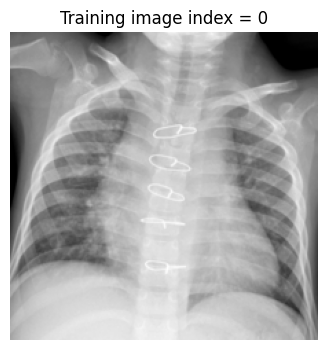

In [ ]:
# Extra ----------------------------------------------------------
# print only one image

ONE_IDX = 0

one_img = train_dataset[ONE_IDX].detach().clone()  # (1, H, W) on GPU
print("Selected index:", ONE_IDX)
print("Shape:", tuple(one_img.shape), "dtype:", one_img.dtype, "device:", one_img.device)
print("min/max:", float(one_img.min()), float(one_img.max()))

plt.figure(figsize=(4,4))
plt.imshow(one_img[0].detach().cpu(), cmap="gray")
plt.title(f"Training image index = {ONE_IDX}")
plt.axis("off")
plt.show()

In [ ]:
# Part nova
# Dataset that repeats the same image
class OneImageDataset(Dataset):
    def __init__(self, img_tensor, length=4096):
        # img_tensor expected (1,H,W) or (1,1,H,W)
        if img_tensor.ndim == 3:
            img_tensor = img_tensor.unsqueeze(0)  # (1,1,H,W)
        self.img = img_tensor
        self.length = length

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        return self.img[0]  # (1,H,W)

one_train = OneImageDataset(one_img, length=4096)

BATCH_SIZE = 32  # good for BatchNorm
one_loader = DataLoader(one_train, batch_size=BATCH_SIZE, shuffle=True)

In [ ]:
# Part nova  Entrenament una sola imatge, per steps no epochs.   Començar amb 4000 steps

model.train()

max_steps = 4000
log_every = 200

it = iter(one_loader)
for step in range(1, max_steps + 1):
    try:
        imgs = next(it)
    except StopIteration:
        it = iter(one_loader)
        imgs = next(it)

    optimizer.zero_grad(set_to_none=True)
    recon = model(imgs)
    loss = loss_fn(recon, imgs)
    loss.backward()
    optimizer.step()

    if step % log_every == 0 or step == 1:
        print(f"step {step}/{max_steps} | loss={loss.item():.6f}")

step 1/4000 | loss=0.103193
step 200/4000 | loss=0.000786
step 400/4000 | loss=0.000381
step 600/4000 | loss=0.000240
step 800/4000 | loss=0.000183
step 1000/4000 | loss=0.000118
step 1200/4000 | loss=0.000150
step 1400/4000 | loss=0.000092
step 1600/4000 | loss=0.000057
step 1800/4000 | loss=0.000050
step 2000/4000 | loss=0.000039
step 2200/4000 | loss=0.000036
step 2400/4000 | loss=0.000028
step 2600/4000 | loss=0.000026
step 2800/4000 | loss=0.000096
step 3000/4000 | loss=0.000229
step 3200/4000 | loss=0.000018
step 3400/4000 | loss=0.000029
step 3600/4000 | loss=0.000020
step 3800/4000 | loss=0.000020
step 4000/4000 | loss=0.000025


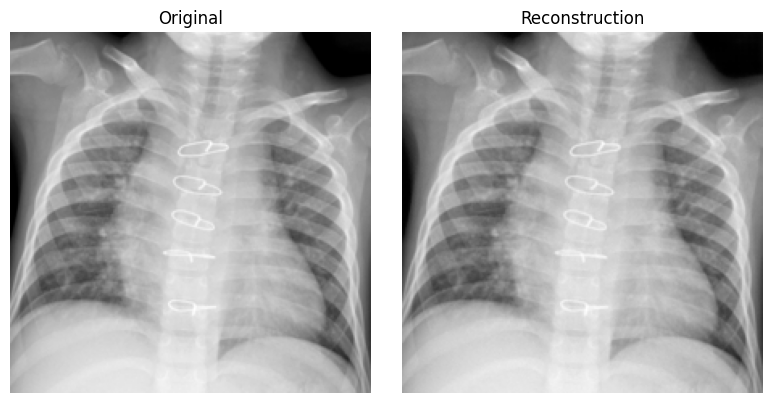

Final MSE: 1.8511887901695445e-05
Final MAE: 0.0032696807757019997


In [ ]:
# Extra: Visualitzar 1 sola imatge
model.eval()
with torch.no_grad():
    x = one_img.unsqueeze(0)  # (1,1,H,W)
    recon = model(x)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(x[0,0].detach().cpu(), cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(recon[0,0].detach().cpu(), cmap="gray")
plt.title("Reconstruction")
plt.axis("off")

plt.tight_layout()
plt.show()

mse = torch.mean((recon - x) ** 2).item()
mae = torch.mean(torch.abs(recon - x)).item()
print("Final MSE:", mse)
print("Final MAE:", mae)